In [1]:
import pandas as pd

C:\Users\Abhishek\AppData\Roaming\Python\Python311\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Abhishek\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# ── Core ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Visualization ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

# ── Preprocessing ─────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE

# ── Models ────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ── Evaluation ────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
    average_precision_score, f1_score
)

# ── Explainability ────────────────────────────────────────────
import shap

# ── Save Model ────────────────────────────────────────────────
import joblib

print(' All libraries imported successfully!')
print(f'Pandas version  : {pd.__version__}')
print(f'NumPy version   : {np.__version__}')

 All libraries imported successfully!
Pandas version  : 3.0.3
NumPy version   : 1.26.4


---
## 📂 SECTION 2 — Load & Understand Data

In [3]:
#  Update path if needed
df = pd.read_csv(r'D:\Mansi\loan-default-scorecard\Data\train.csv')

print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')

Rows    : 233,154
Columns : 41


In [4]:
# First look
df.head()

,UniqueID,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Date.of.Birth,Employment.Type,DisbursalDate,State_ID,Employee_code_ID,MobileNo_Avl_Flag,Aadhar_flag,PAN_flag,VoterID_flag,Driving_flag,Passport_flag,PERFORM_CNS.SCORE,PERFORM_CNS.SCORE.DESCRIPTION,PRI.NO.OF.ACCTS,PRI.ACTIVE.ACCTS,PRI.OVERDUE.ACCTS,PRI.CURRENT.BALANCE,PRI.SANCTIONED.AMOUNT,PRI.DISBURSED.AMOUNT,SEC.NO.OF.ACCTS,SEC.ACTIVE.ACCTS,SEC.OVERDUE.ACCTS,SEC.CURRENT.BALANCE,SEC.SANCTIONED.AMOUNT,SEC.DISBURSED.AMOUNT,PRIMARY.INSTAL.AMT,SEC.INSTAL.AMT,NEW.ACCTS.IN.LAST.SIX.MONTHS,DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS,AVERAGE.ACCT.AGE,CREDIT.HISTORY.LENGTH,NO.OF_INQUIRIES,loan_default
0,420825,50578,58400,89.55,67,22807,45,1441,01-01-84,Salaried,03-08-18,6,1998,1,1,0,0,0,0,0,No Bureau History Available,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
1,537409,47145,65550,73.23,67,22807,45,1502,31-07-85,Self employed,26-09-18,6,1998,1,1,0,0,0,0,598,I-Medium Risk,1,1,1,27600,50200,50200,0,0,0,0,0,0,1991,0,0,1,1yrs 11mon,1yrs 11mon,0,1
2,417566,53278,61360,89.63,67,22807,45,1497,24-08-85,Self employed,01-08-18,6,1998,1,1,0,0,0,0,0,No Bureau History Available,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
3,624493,57513,66113,88.48,67,22807,45,1501,30-12-93,Self employed,26-10-18,6,1998,1,1,0,0,0,0,305,L-Very High Risk,3,0,0,0,0,0,0,0,0,0,0,0,31,0,0,0,0yrs 8mon,1yrs 3mon,1,1
4,539055,52378,60300,88.39,67,22807,45,1495,09-12-77,Self employed,26-09-18,6,1998,1,1,0,0,0,0,0,No Bureau History Available,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,1,1


In [5]:
# Data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 233154 entries, 0 to 233153
Data columns (total 41 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   UniqueID                             233154 non-null  int64  
 1   disbursed_amount                     233154 non-null  int64  
 2   asset_cost                           233154 non-null  int64  
 3   ltv                                  233154 non-null  float64
 4   branch_id                            233154 non-null  int64  
 5   supplier_id                          233154 non-null  int64  
 6   manufacturer_id                      233154 non-null  int64  
 7   Current_pincode_ID                   233154 non-null  int64  
 8   Date.of.Birth                        233154 non-null  str    
 9   Employment.Type                      225493 non-null  str    
 10  DisbursalDate                        233154 non-null  str    
 11  State_ID                

In [6]:
# Statistical summary
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
UniqueID,233154.000000,535917.573376,68315.693711,417428.000000,476786.250000,535978.500000,595039.750000,671084.000000
disbursed_amount,233154.000000,54356.993528,12971.314171,13320.000000,47145.000000,53803.000000,60413.000000,990572.000000
asset_cost,233154.000000,75865.068144,18944.781289,37000.000000,65717.000000,70946.000000,79201.750000,1628992.000000
ltv,233154.000000,74.746530,11.456636,10.030000,68.880000,76.800000,83.670000,95.000000
branch_id,233154.000000,72.936094,69.834995,1.000000,14.000000,61.000000,130.000000,261.000000
supplier_id,233154.000000,19638.635035,3491.949566,10524.000000,16535.000000,20333.000000,23000.000000,24803.000000
manufacturer_id,233154.000000,69.028054,22.141304,45.000000,48.000000,86.000000,86.000000,156.000000
Current_pincode_ID,233154.000000,3396.880247,2238.147502,1.000000,1511.000000,2970.000000,5677.000000,7345.000000
State_ID,233154.000000,7.262243,4.482230,1.000000,4.000000,6.000000,10.000000,22.000000
Employee_code_ID,233154.000000,1549.477148,975.261278,1.000000,713.000000,1451.000000,2362.000000,3795.000000


In [7]:
# Identify column types
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in num_cols if c != 'loan_default']

print(f'Numerical columns  ({len(num_cols)}): {num_cols}')
print(f'\nCategorical columns ({len(cat_cols)}): {cat_cols}')

Numerical columns  (34): ['UniqueID', 'disbursed_amount', 'asset_cost', 'ltv', 'branch_id', 'supplier_id', 'manufacturer_id', 'Current_pincode_ID', 'State_ID', 'Employee_code_ID', 'MobileNo_Avl_Flag', 'Aadhar_flag', 'PAN_flag', 'VoterID_flag', 'Driving_flag', 'Passport_flag', 'PERFORM_CNS.SCORE', 'PRI.NO.OF.ACCTS', 'PRI.ACTIVE.ACCTS', 'PRI.OVERDUE.ACCTS', 'PRI.CURRENT.BALANCE', 'PRI.SANCTIONED.AMOUNT', 'PRI.DISBURSED.AMOUNT', 'SEC.NO.OF.ACCTS', 'SEC.ACTIVE.ACCTS', 'SEC.OVERDUE.ACCTS', 'SEC.CURRENT.BALANCE', 'SEC.SANCTIONED.AMOUNT', 'SEC.DISBURSED.AMOUNT', 'PRIMARY.INSTAL.AMT', 'SEC.INSTAL.AMT', 'NEW.ACCTS.IN.LAST.SIX.MONTHS', 'DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS', 'NO.OF_INQUIRIES']

Categorical columns (6): ['Date.of.Birth', 'Employment.Type', 'DisbursalDate', 'PERFORM_CNS.SCORE.DESCRIPTION', 'AVERAGE.ACCT.AGE', 'CREDIT.HISTORY.LENGTH']


Columns with missing values:


,Missing Count,Missing %
Employment.Type,7661,3.285811


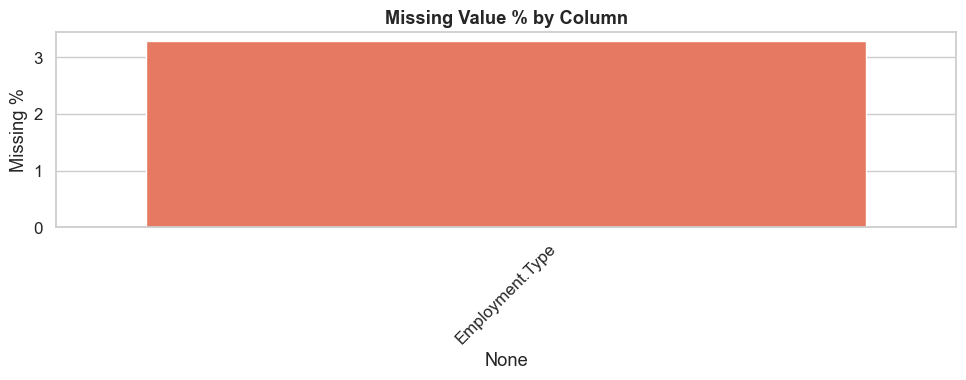

In [8]:
# Missing value analysis
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %'    : (df.isnull().sum() / len(df)) * 100
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

if len(missing) > 0:
    print('Columns with missing values:')
    display(missing.style.background_gradient(cmap='Reds'))

    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing.index, y='Missing %', data=missing, palette='Reds_r')
    plt.title('Missing Value % by Column', fontweight='bold')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('pip install jinja2 No missing values found!')

  TARGET VARIABLE: loan_default
  No Default (0) : 182,543  (78.3%)
  Default    (1) :  50,611  (21.7%)
  Imbalance Ratio: 3.6 : 1
  → SMOTE will be applied to fix imbalance


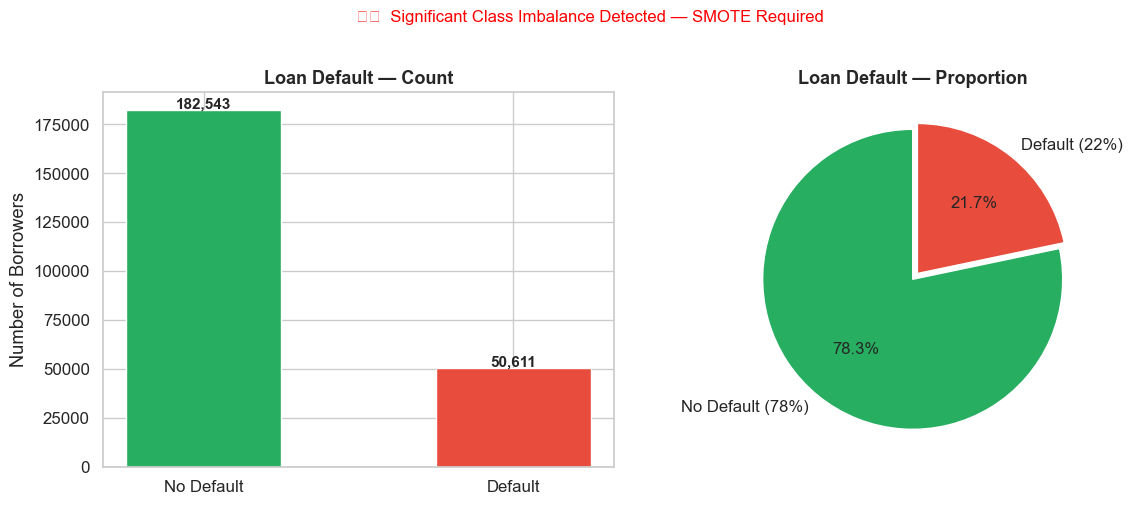

In [9]:
target_counts = df['loan_default'].value_counts()
target_pct    = df['loan_default'].value_counts(normalize=True) * 100

print('='*45)
print('  TARGET VARIABLE: loan_default')
print('='*45)
print(f'  No Default (0) : {target_counts[0]:>7,}  ({target_pct[0]:.1f}%)')
print(f'  Default    (1) : {target_counts[1]:>7,}  ({target_pct[1]:.1f}%)')
print(f'  Imbalance Ratio: {target_counts[0]/target_counts[1]:.1f} : 1')
print('  → SMOTE will be applied to fix imbalance')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count bar
bars = axes[0].bar(['No Default', 'Default'], target_counts.values,
                    color=['#27ae60','#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Loan Default — Count', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Borrowers')
for bar, val in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500, f'{val:,}',
                 ha='center', fontweight='bold', fontsize=11)

# Pie
axes[1].pie(target_counts.values,
            labels=['No Default (78%)','Default (22%)'],
            colors=['#27ae60','#e74c3c'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize':12},
            explode=(0, 0.05))
axes[1].set_title('Loan Default — Proportion', fontweight='bold', fontsize=13)

plt.suptitle('⚠️  Significant Class Imbalance Detected — SMOTE Required',
             fontsize=12, color='red', y=1.01)
plt.tight_layout()
plt.show()

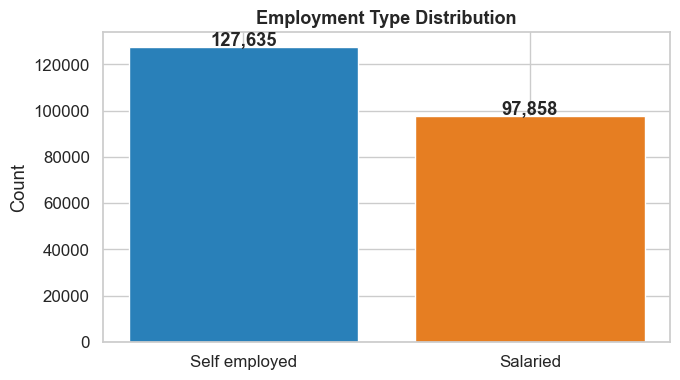

In [11]:
# Employment Type distribution
if 'Employment.Type' in df.columns:
    plt.figure(figsize=(7, 4))
    emp_counts = df['Employment.Type'].value_counts()
    bars = plt.bar(emp_counts.index, emp_counts.values,
                   color=['#2980b9','#e67e22'], edgecolor='white')
    plt.title('Employment Type Distribution', fontweight='bold', fontsize=13)
    plt.ylabel('Count')
    for bar, val in zip(bars, emp_counts.values):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 300,
                 f'{val:,}', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 🔍 SECTION 5 — Bivariate Analysis (Features vs Default)

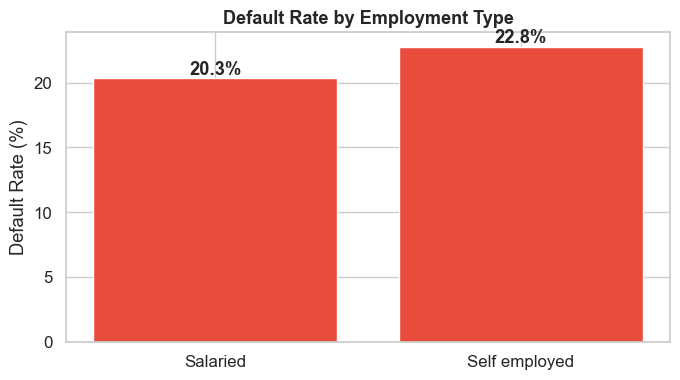

In [12]:
# Employment Type vs Default Rate
if 'Employment.Type' in df.columns:
    emp_default = df.groupby('Employment.Type')['loan_default'].mean() * 100

    plt.figure(figsize=(7, 4))
    bars = plt.bar(emp_default.index, emp_default.values,
                   color=['#27ae60' if x < 20 else '#e74c3c'
                          for x in emp_default.values],
                   edgecolor='white')
    plt.title('Default Rate by Employment Type', fontweight='bold', fontsize=13)
    plt.ylabel('Default Rate (%)')
    for bar, val in zip(bars, emp_default.values):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

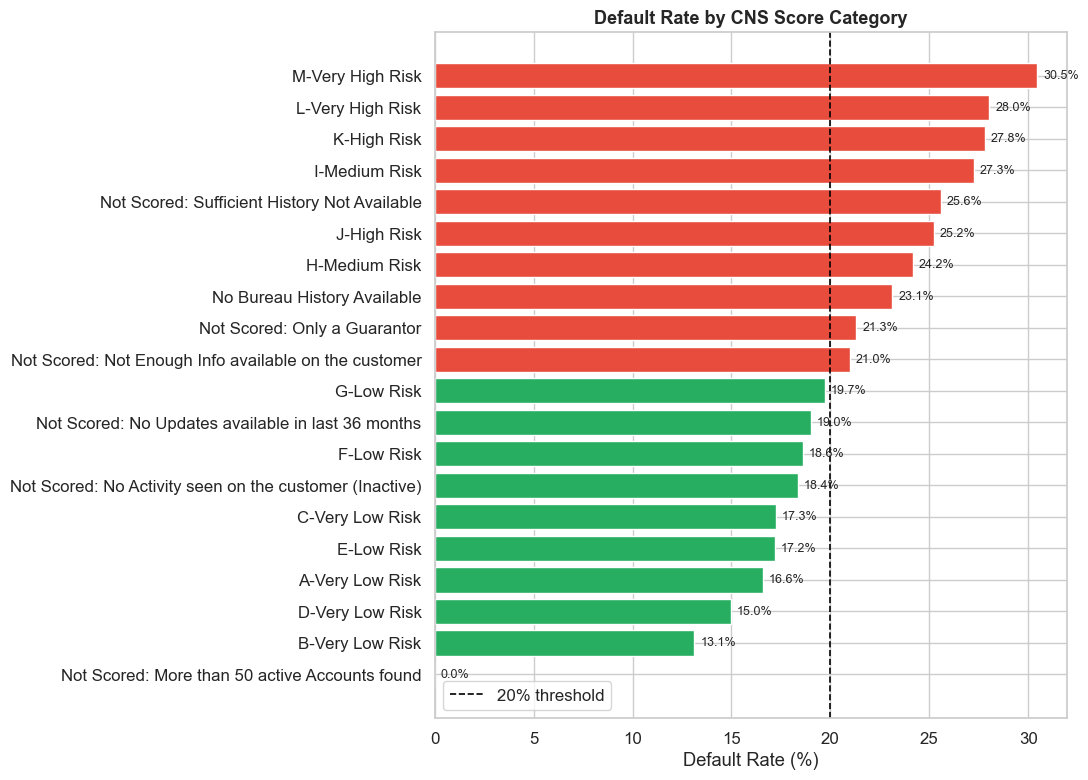

In [13]:
# CNS Score Description vs Default (horizontal bar)
if 'PERFORM_CNS.SCORE.DESCRIPTION' in df.columns:
    cns_default = (df.groupby('PERFORM_CNS.SCORE.DESCRIPTION')['loan_default']
                   .mean() * 100).sort_values(ascending=True)

    plt.figure(figsize=(11, 8))
    bars = plt.barh(cns_default.index, cns_default.values,
                    color=['#e74c3c' if x > 20 else '#27ae60'
                           for x in cns_default.values],
                    edgecolor='white')
    plt.axvline(x=20, color='black', linestyle='--',
                linewidth=1.2, label='20% threshold')
    plt.title('Default Rate by CNS Score Category',
              fontweight='bold', fontsize=13)
    plt.xlabel('Default Rate (%)')
    for bar, val in zip(bars, cns_default.values):
        plt.text(val + 0.3,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)
    plt.legend()
    plt.tight_layout()
    plt.show()

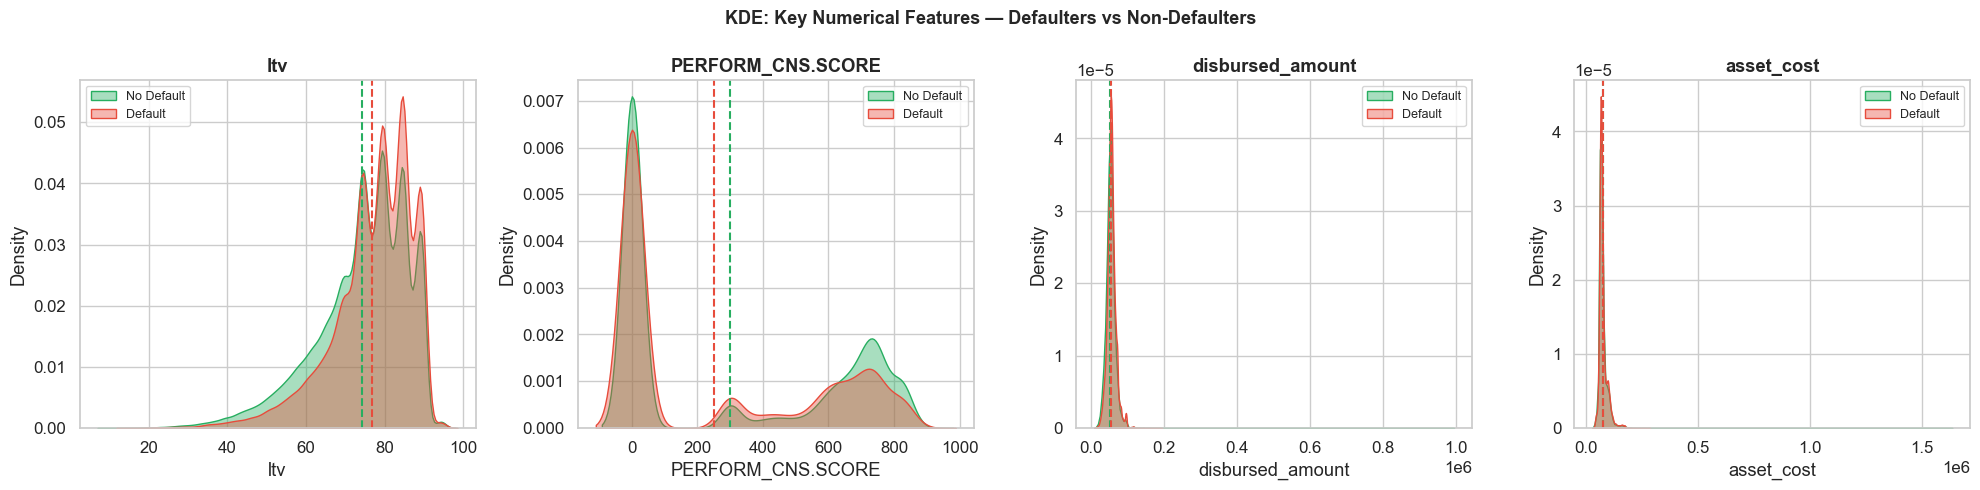

In [14]:
# KDE plots — key numerical features vs default
kde_features = ['ltv', 'PERFORM_CNS.SCORE', 'disbursed_amount', 'asset_cost']
kde_features = [f for f in kde_features if f in df.columns]

fig, axes = plt.subplots(1, len(kde_features), figsize=(20, 5))

for i, col in enumerate(kde_features):
    sns.kdeplot(data=df[df['loan_default']==0][col].dropna(),
                ax=axes[i], label='No Default',
                color='#27ae60', fill=True, alpha=0.4)
    sns.kdeplot(data=df[df['loan_default']==1][col].dropna(),
                ax=axes[i], label='Default',
                color='#e74c3c', fill=True, alpha=0.4)

    # Mean lines
    m0 = df[df['loan_default']==0][col].mean()
    m1 = df[df['loan_default']==1][col].mean()
    axes[i].axvline(m0, color='#27ae60', linestyle='--', linewidth=1.5)
    axes[i].axvline(m1, color='#e74c3c', linestyle='--', linewidth=1.5)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=9)

plt.suptitle('KDE: Key Numerical Features — Defaulters vs Non-Defaulters',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
print(df['loan_default'].dtype)
print(df['loan_default'].unique())

int64
[0 1]


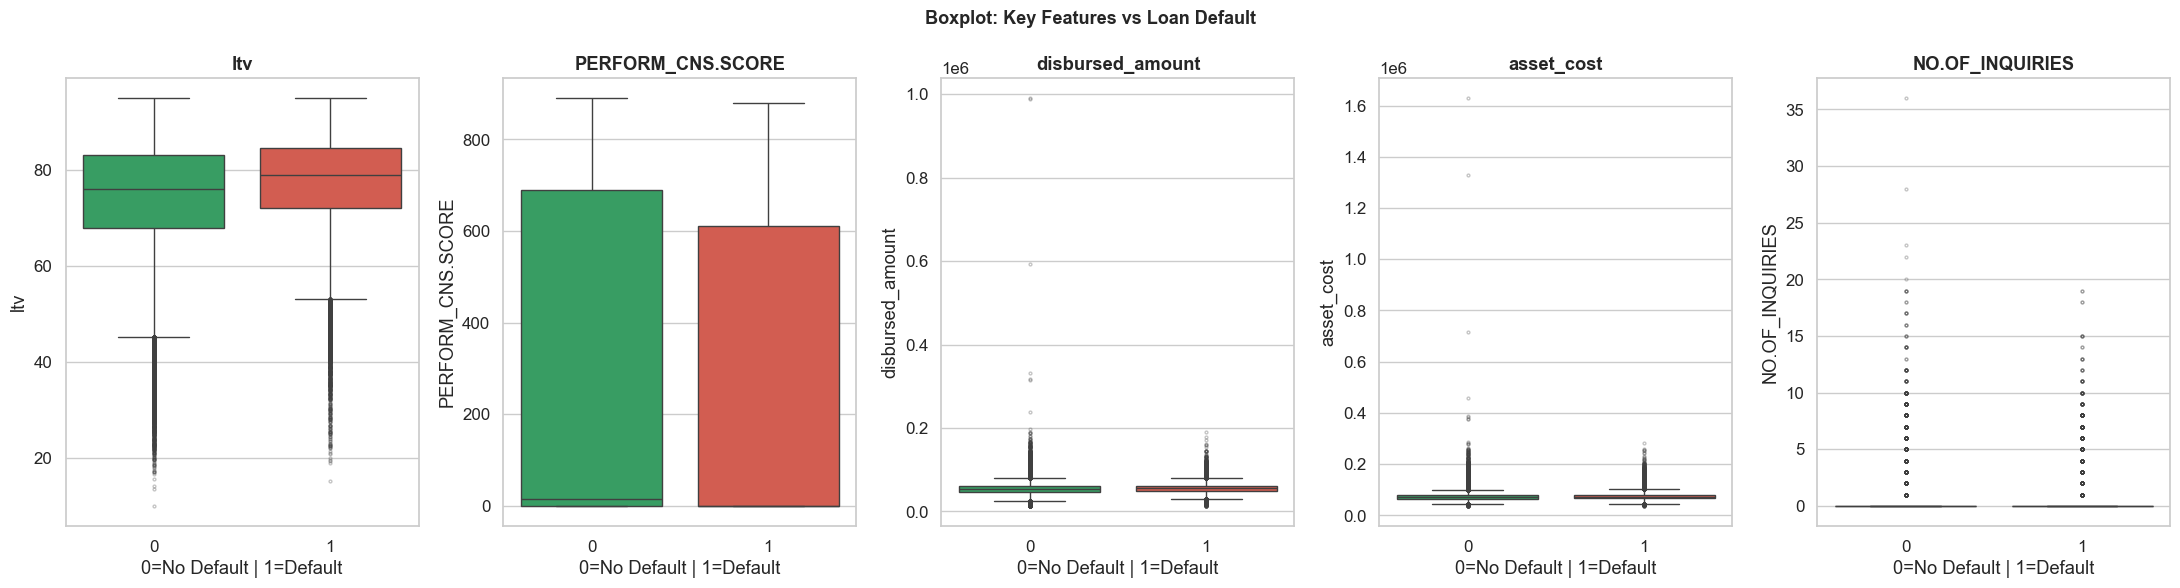

In [16]:
# Boxplots — key features vs default
box_features = ['ltv', 'PERFORM_CNS.SCORE', 'disbursed_amount',
                'asset_cost', 'NO.OF_INQUIRIES']
box_features = [f for f in box_features if f in df.columns]

fig, axes = plt.subplots(1, len(box_features), figsize=(22, 6))

for i, col in enumerate(box_features):
    sns.boxplot(
        x='loan_default',
        y=col,
        data=df,
        palette={'0': '#27ae60', '1': '#e74c3c'},
        ax=axes[i],
        flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3}
    )

    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('0=No Default | 1=Default')

plt.suptitle(
    'Boxplot: Key Features vs Loan Default',
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

In [17]:
# Age group analysis
if 'Age' in df.columns:
    df['age_group'] = pd.cut(df['Age'],
                              bins=[18, 25, 30, 35, 40, 50, 100],
                              labels=['18-25','25-30','30-35',
                                      '35-40','40-50','50+'])
    age_default = (df.groupby('age_group', observed=True)['loan_default']
                   .mean() * 100)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    axes[0].hist(df[df['loan_default']==0]['Age'].dropna(),
                 bins=30, alpha=0.6, color='#27ae60', label='No Default')
    axes[0].hist(df[df['loan_default']==1]['Age'].dropna(),
                 bins=30, alpha=0.6, color='#e74c3c', label='Default')
    axes[0].set_title('Age Distribution by Default Status',
                       fontweight='bold')
    axes[0].set_xlabel('Age')
    axes[0].legend()

    # Default rate by group
    bars = axes[1].bar(age_default.index.astype(str),
                        age_default.values,
                        color='#e74c3c', edgecolor='white')
    axes[1].set_title('Default Rate by Age Group', fontweight='bold')
    axes[1].set_xlabel('Age Group')
    axes[1].set_ylabel('Default Rate (%)')
    for bar, val in zip(bars, age_default.values):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.2,
                     f'{val:.1f}%', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

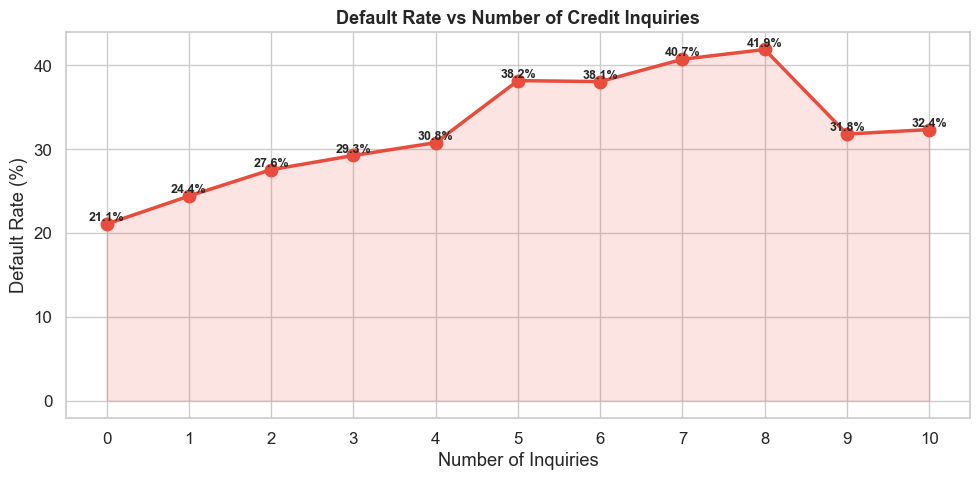

In [18]:
# Inquiry count vs default rate (line chart)
if 'NO.OF_INQUIRIES' in df.columns:
    inq = (df[df['NO.OF_INQUIRIES'] <= 10]
           .groupby('NO.OF_INQUIRIES')['loan_default']
           .mean() * 100)

    plt.figure(figsize=(10, 5))
    plt.plot(inq.index, inq.values, marker='o',
             color='#e74c3c', linewidth=2.5, markersize=9)
    plt.fill_between(inq.index, inq.values, alpha=0.15, color='#e74c3c')
    for x, y in zip(inq.index, inq.values):
        plt.text(x, y + 0.4, f'{y:.1f}%', ha='center',
                 fontsize=9, fontweight='bold')
    plt.title('Default Rate vs Number of Credit Inquiries',
              fontweight='bold', fontsize=13)
    plt.xlabel('Number of Inquiries')
    plt.ylabel('Default Rate (%)')
    plt.xticks(inq.index)
    plt.tight_layout()
    plt.show()

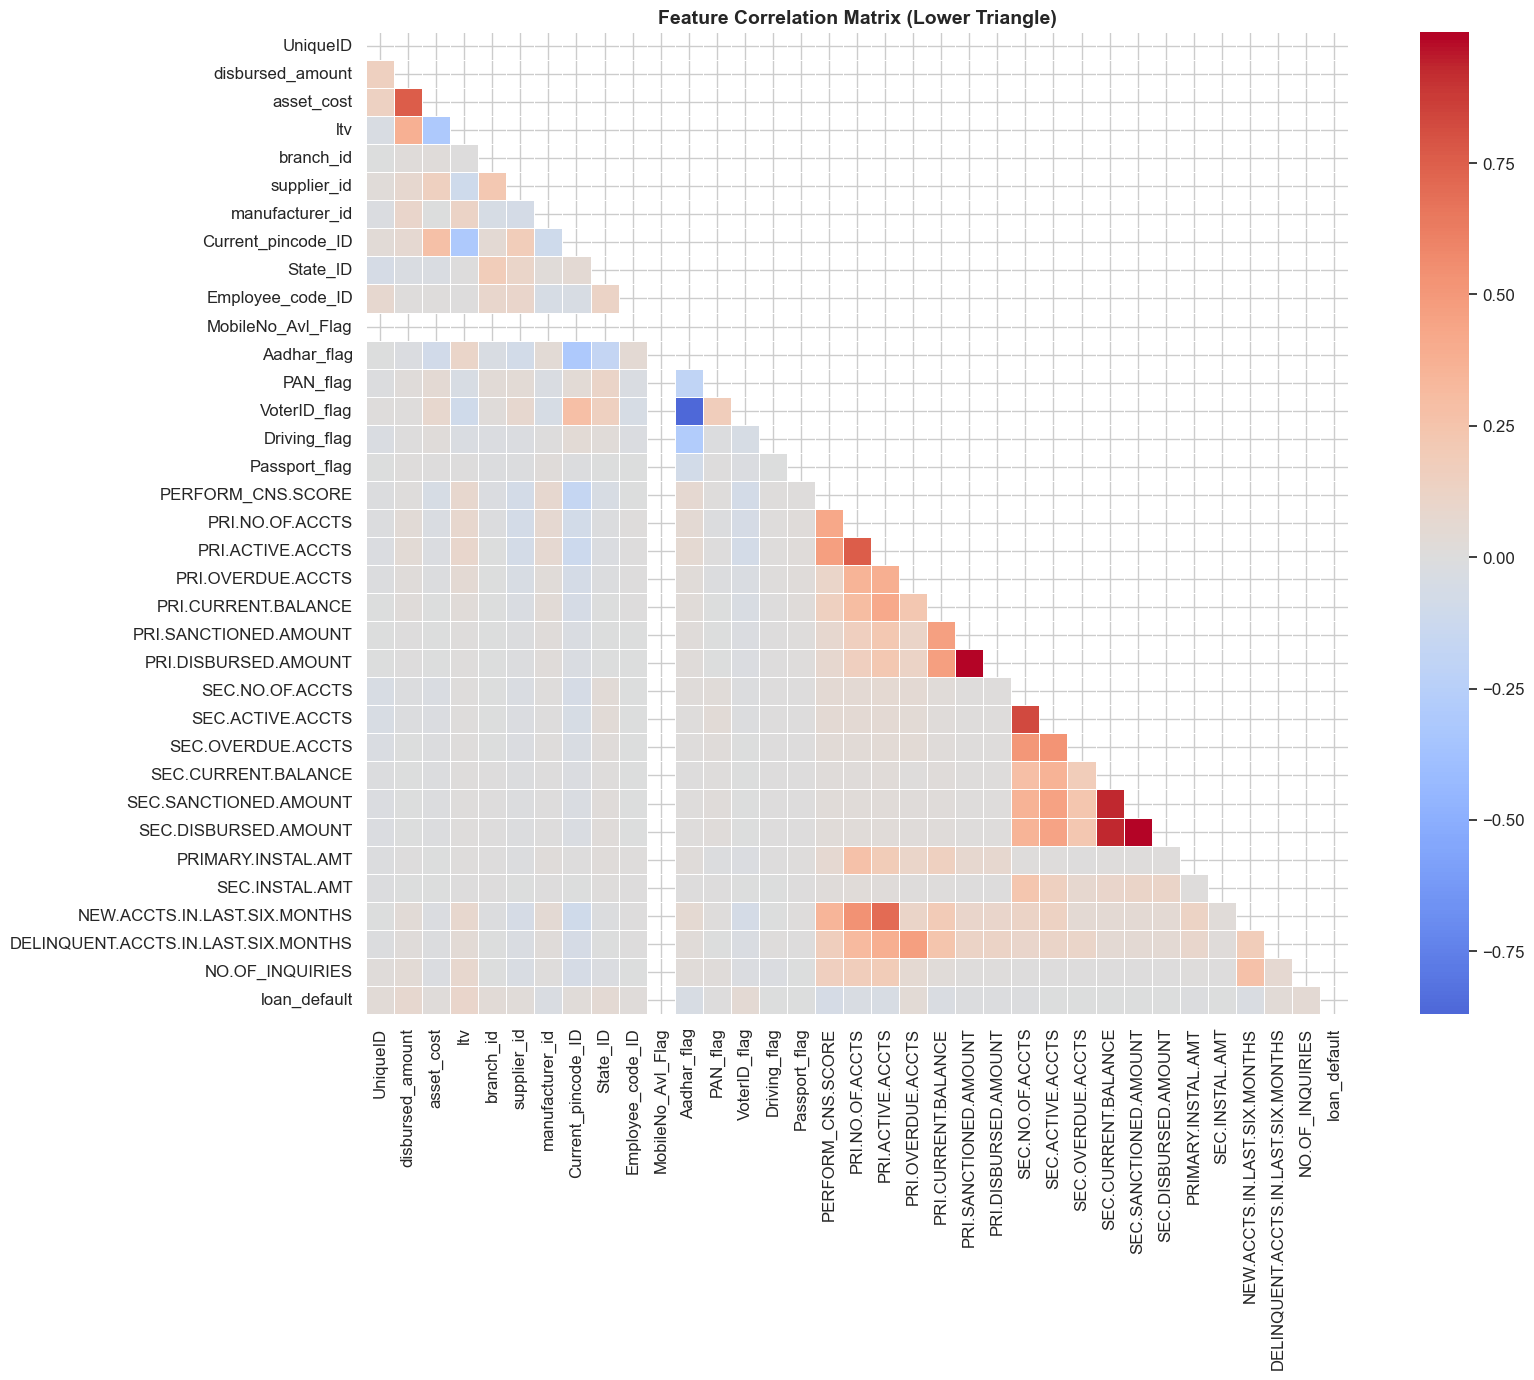

In [19]:
# Lower-triangle correlation heatmap
corr = df[num_cols + ['loan_default']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(18, 14))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.4, square=True)
plt.title('Feature Correlation Matrix (Lower Triangle)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

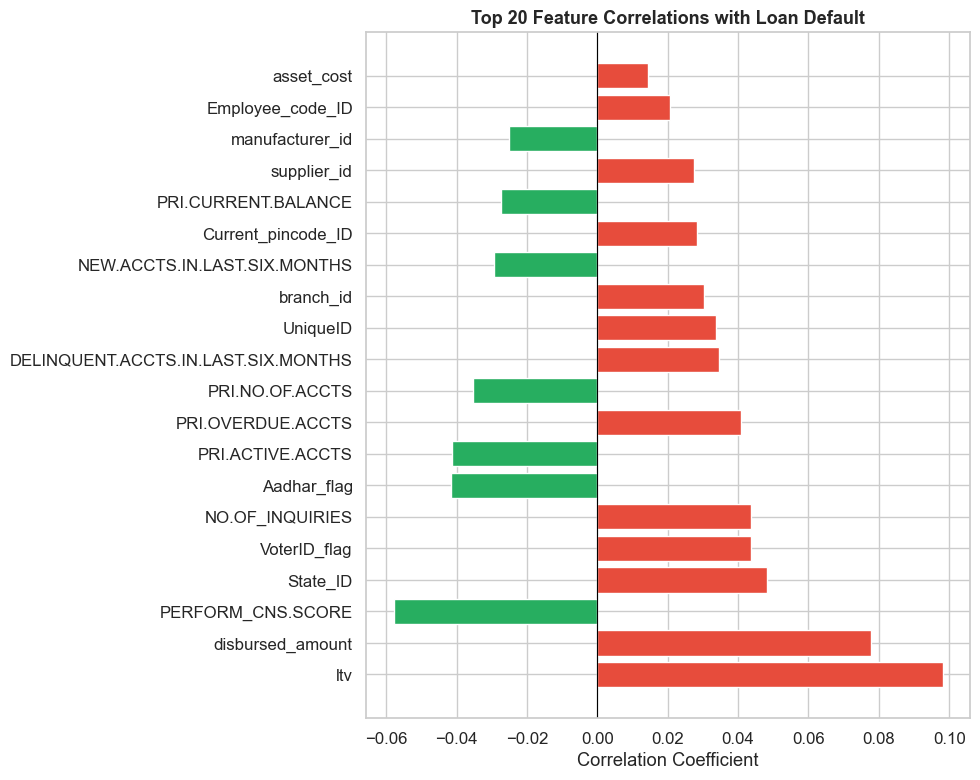

In [20]:
# Top feature correlations with target
target_corr = (corr['loan_default']
               .drop('loan_default')
               .sort_values(key=abs, ascending=False)
               .head(20))

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if x > 0 else '#27ae60' for x in target_corr.values]
plt.barh(target_corr.index, target_corr.values,
         color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 20 Feature Correlations with Loan Default',
          fontsize=13, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [21]:
df_fe = df.copy()
new_feats = []

# 1. Loan-to-Asset Ratio
if all(c in df_fe.columns for c in ['disbursed_amount','asset_cost']):
    df_fe['loan_to_asset_ratio'] = (
        df_fe['disbursed_amount'] / (df_fe['asset_cost'] + 1))
    new_feats.append('loan_to_asset_ratio')

# 2. CNS Score Band
if 'PERFORM_CNS.SCORE' in df_fe.columns:
    df_fe['cns_band'] = pd.cut(
        df_fe['PERFORM_CNS.SCORE'],
        bins=[0, 300, 500, 650, 750, 1000],
        labels=['Very Poor','Poor','Fair','Good','Excellent'])
    new_feats.append('cns_band')

# 3. High Inquiry Flag (> 3 inquiries = risky)
if 'NO.OF_INQUIRIES' in df_fe.columns:
    df_fe['high_inquiry_flag'] = (df_fe['NO.OF_INQUIRIES'] > 3).astype(int)
    new_feats.append('high_inquiry_flag')

# 4. High LTV Flag (> 80% = high risk)
if 'ltv' in df_fe.columns:
    df_fe['high_ltv_flag'] = (df_fe['ltv'] > 80).astype(int)
    new_feats.append('high_ltv_flag')

# 5. Young Borrower Flag (< 30 years)
if 'Age' in df_fe.columns:
    df_fe['young_borrower'] = (df_fe['Age'] < 30).astype(int)
    new_feats.append('young_borrower')

# 6. Total Accounts
if all(c in df_fe.columns for c in ['PRI.NO.OF.ACCTS','SEC.NO.OF.ACCTS']):
    df_fe['total_accounts'] = (
        df_fe['PRI.NO.OF.ACCTS'] + df_fe['SEC.NO.OF.ACCTS'])
    new_feats.append('total_accounts')

# 7. Active Account Ratio
if all(c in df_fe.columns for c in ['PRI.ACTIVE.ACCTS','PRI.NO.OF.ACCTS']):
    df_fe['active_acct_ratio'] = (
        df_fe['PRI.ACTIVE.ACCTS'] / (df_fe['PRI.NO.OF.ACCTS'] + 1))
    new_feats.append('active_acct_ratio')

# 8. Overdue Flag
if 'PRI.OVERDUE.ACCTS' in df_fe.columns:
    df_fe['has_overdue'] = (df_fe['PRI.OVERDUE.ACCTS'] > 0).astype(int)
    new_feats.append('has_overdue')

print(f'✅ {len(new_feats)} new features created:')
for f in new_feats:
    print(f'   → {f}')
print(f'\nNew shape: {df_fe.shape}')

✅ 7 new features created:
   → loan_to_asset_ratio
   → cns_band
   → high_inquiry_flag
   → high_ltv_flag
   → total_accounts
   → active_acct_ratio
   → has_overdue

New shape: (233154, 48)


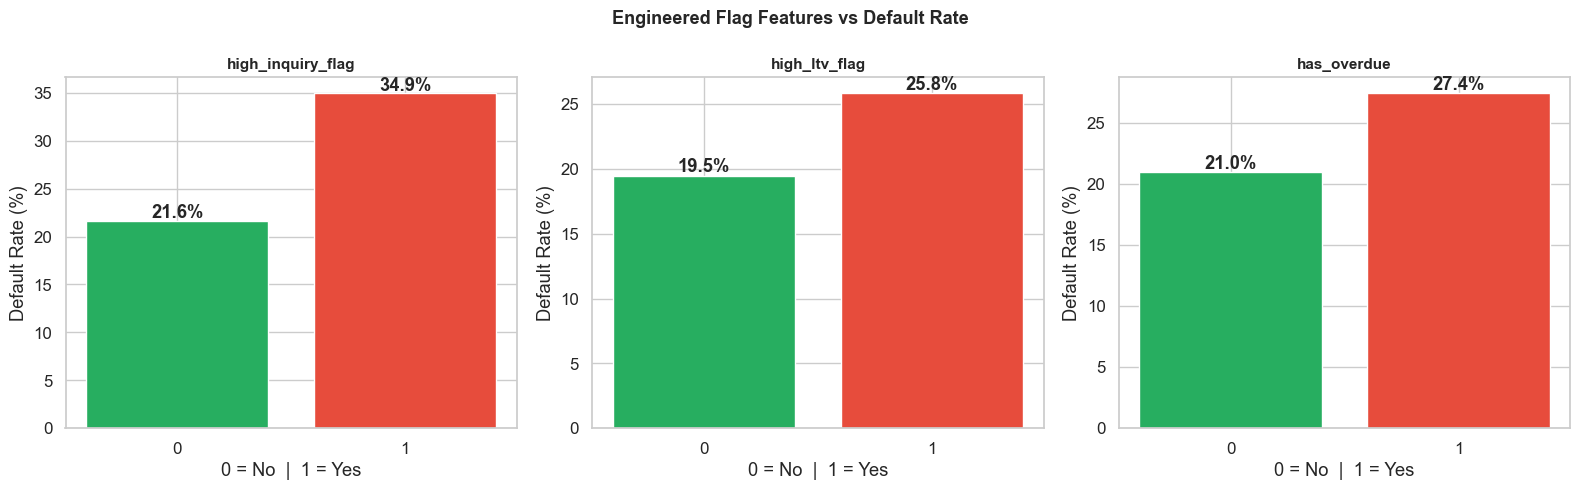

In [22]:
# Visualise engineered features vs default
flag_feats = ['high_inquiry_flag','high_ltv_flag','young_borrower','has_overdue']
flag_feats = [f for f in flag_feats if f in df_fe.columns]

fig, axes = plt.subplots(1, len(flag_feats), figsize=(16, 5))

for i, col in enumerate(flag_feats):
    dr = df_fe.groupby(col)['loan_default'].mean() * 100
    bars = axes[i].bar(dr.index.astype(str), dr.values,
                        color=['#27ae60','#e74c3c'], edgecolor='white')
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].set_xlabel('0 = No  |  1 = Yes')
    for bar, val in zip(bars, dr.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Engineered Flag Features vs Default Rate',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🧹 SECTION 8 — Preprocessing

In [23]:
df_model = df_fe.copy()

# Drop ID, date, and helper columns
drop_cols = ['UniqueID','Date.of.Birth','DisbursalDate',
             'age_group','cns_band']
drop_cols = [c for c in drop_cols if c in df_model.columns]
df_model.drop(columns=drop_cols, inplace=True)
print(f'✅ Dropped: {drop_cols}')

# Refresh column type lists
num_m = df_model.select_dtypes(include=['int64','float64']).columns.tolist()
cat_m = df_model.select_dtypes(include='object').columns.tolist()
num_m = [c for c in num_m if c != 'loan_default']

# Fill missing
for col in num_m:
    df_model[col].fillna(df_model[col].median(), inplace=True)
for col in cat_m:
    df_model[col].fillna(df_model[col].mode()[0], inplace=True)
print('✅ Missing values filled')

# Label encode categoricals
le = LabelEncoder()
for col in cat_m:
    df_model[col] = le.fit_transform(df_model[col].astype(str))
print('✅ Categorical columns encoded')
print(f'Final model shape: {df_model.shape}')

✅ Dropped: ['UniqueID', 'Date.of.Birth', 'DisbursalDate', 'cns_band']
✅ Missing values filled
✅ Categorical columns encoded
Final model shape: (233154, 44)


Train size  : 186,523  →  after SMOTE: 292,068
Test size   : 46,631
Before SMOTE: {0: 146034, 1: 40489}
After  SMOTE: {1: 146034, 0: 146034}


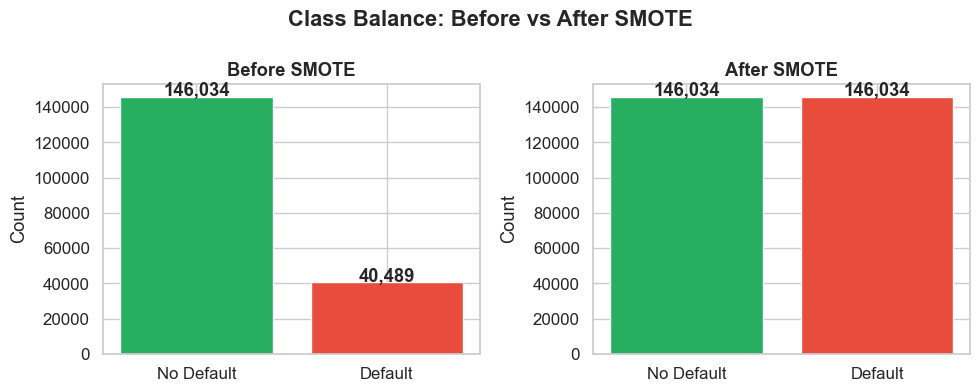

In [ ]:
# Features & target
X = df_model.drop('loan_default', axis=1)
y = df_model['loan_default']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE on training set only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'Train size  : {X_train.shape[0]:,}  →  after SMOTE: {X_train_sm.shape[0]:,}')
print(f'Test size   : {X_test.shape[0]:,}')
print(f'Before SMOTE: {dict(y_train.value_counts())}')
print(f'After  SMOTE: {dict(pd.Series(y_train_sm).value_counts())}')

# SMOTE comparison chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, title, counts in zip(
    axes,
    ['Before SMOTE', 'After SMOTE'],
    [y_train.value_counts(), pd.Series(y_train_sm).value_counts()]
):
    ax.bar(['No Default','Default'], counts.values,
           color=['#27ae60','#e74c3c'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Class Balance: Before vs After SMOTE', fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# Logistic Regression
print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]
print(f'Done — ROC-AUC: {roc_auc_score(y_test, lr_prob):.4f}')

Training Logistic Regression...
Done — ROC-AUC: 0.5880


In [26]:
# Random Forest
print(' Training Random Forest (3-5 mins)...')
rf = RandomForestClassifier(n_estimators=100, random_state=42,
                             n_jobs=-1, max_depth=10)
rf.fit(X_train_sm, y_train_sm)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]
print(f' Done — ROC-AUC: {roc_auc_score(y_test, rf_prob):.4f}')

 Training Random Forest (3-5 mins)...
 Done — ROC-AUC: 0.6173


In [27]:
# XGBoost
print(' Training XGBoost...')
xgb = XGBClassifier(n_estimators=100, random_state=42,
                     eval_metric='logloss', n_jobs=-1,
                     max_depth=6, learning_rate=0.1)
xgb.fit(X_train_sm, y_train_sm)
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]
print(f' Done — ROC-AUC: {roc_auc_score(y_test, xgb_prob):.4f}')

 Training XGBoost...
 Done — ROC-AUC: 0.6315


---
## 📊 SECTION 10 — Model Evaluation

,Model,ROC-AUC,F1-Score,Avg Precision
0,Logistic Regression,0.588000,0.365100,0.268600
1,Random Forest,0.617300,0.306100,0.290700
2,XGBoost,0.631500,0.194800,0.303100


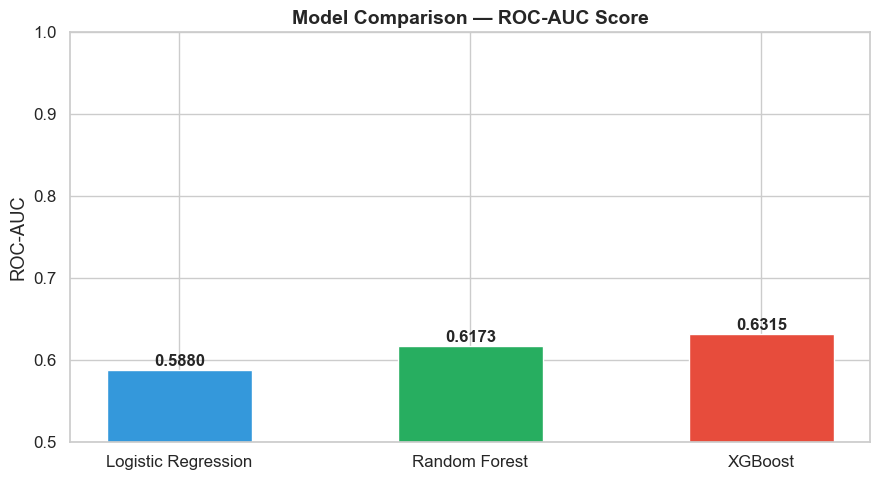

In [28]:
# Summary table
models_info = [
    ('Logistic Regression', lr_pred, lr_prob),
    ('Random Forest',       rf_pred, rf_prob),
    ('XGBoost',             xgb_pred, xgb_prob)
]

summary = pd.DataFrame([
    {
        'Model'    : name,
        'ROC-AUC'  : round(roc_auc_score(y_test, prob), 4),
        'F1-Score' : round(f1_score(y_test, pred), 4),
        'Avg Precision': round(average_precision_score(y_test, prob), 4)
    }
    for name, pred, prob in models_info
])

display(summary.style.highlight_max(
    subset=['ROC-AUC','F1-Score','Avg Precision'],
    color='#abebc6'))

# Bar chart
plt.figure(figsize=(9, 5))
bars = plt.bar(summary['Model'], summary['ROC-AUC'],
               color=['#3498db','#27ae60','#e74c3c'],
               edgecolor='white', width=0.5)
plt.ylim(0.5, 1.0)
plt.title('Model Comparison — ROC-AUC Score',
          fontsize=14, fontweight='bold')
plt.ylabel('ROC-AUC')
for bar, val in zip(bars, summary['ROC-AUC']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.4f}', ha='center',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

In [29]:
# Classification reports
for name, pred, prob in models_info:
    print('='*50)
    print(f'  {name}')
    print(f'  ROC-AUC: {roc_auc_score(y_test, prob):.4f}')
    print(classification_report(y_test, pred,
          target_names=['No Default','Default']))

  Logistic Regression
  ROC-AUC: 0.5880
              precision    recall  f1-score   support

  No Default       0.83      0.50      0.62     36509
     Default       0.26      0.63      0.37     10122

    accuracy                           0.52     46631
   macro avg       0.54      0.56      0.49     46631
weighted avg       0.70      0.52      0.56     46631

  Random Forest
  ROC-AUC: 0.6173
              precision    recall  f1-score   support

  No Default       0.81      0.80      0.81     36509
     Default       0.30      0.31      0.31     10122

    accuracy                           0.70     46631
   macro avg       0.56      0.56      0.56     46631
weighted avg       0.70      0.70      0.70     46631

  XGBoost
  ROC-AUC: 0.6315
              precision    recall  f1-score   support

  No Default       0.79      0.93      0.86     36509
     Default       0.34      0.14      0.19     10122

    accuracy                           0.76     46631
   macro avg       0.57   

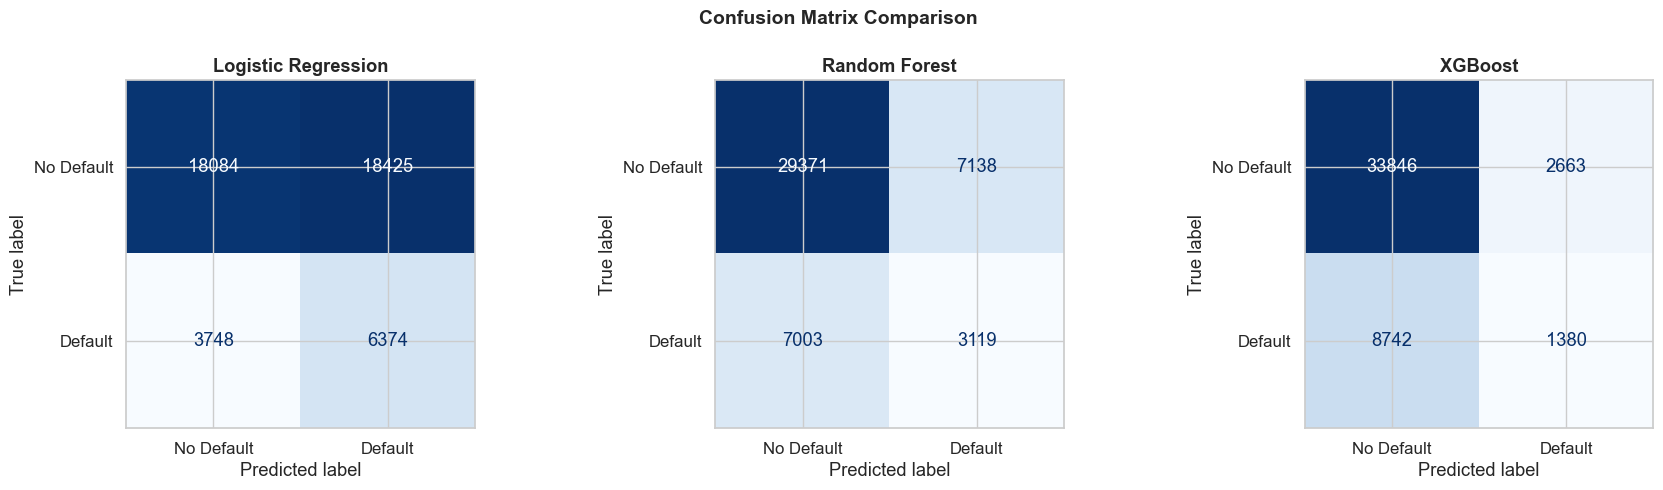

In [30]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, pred, _) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Default','Default']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrix Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

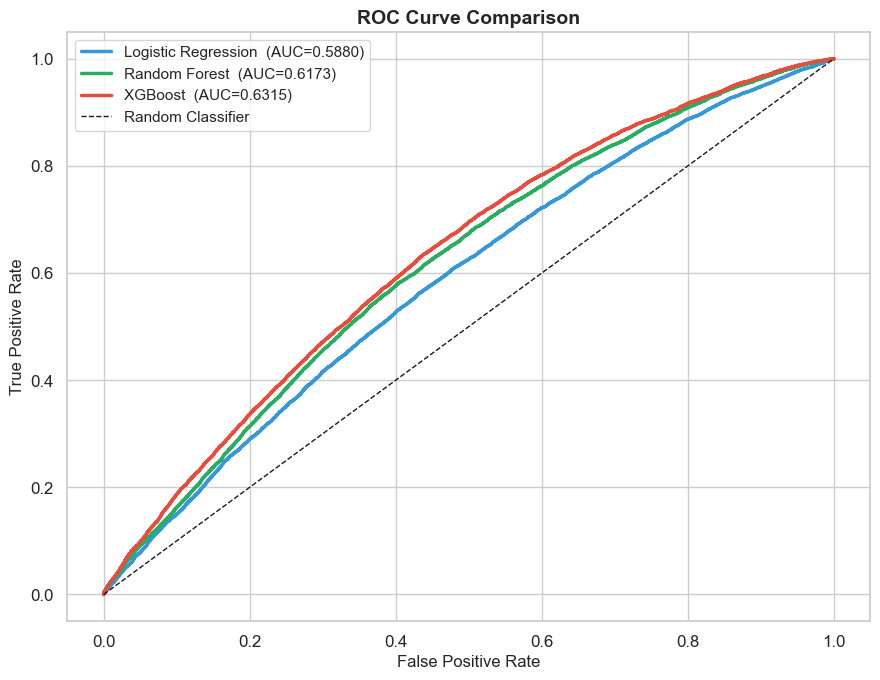

In [31]:
# ROC Curves
plt.figure(figsize=(9, 7))
colors = ['#3498db','#27ae60','#e74c3c']

for (name, _, prob), color in zip(models_info, colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name}  (AUC={auc:.4f})',
             color=color, linewidth=2.5)

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

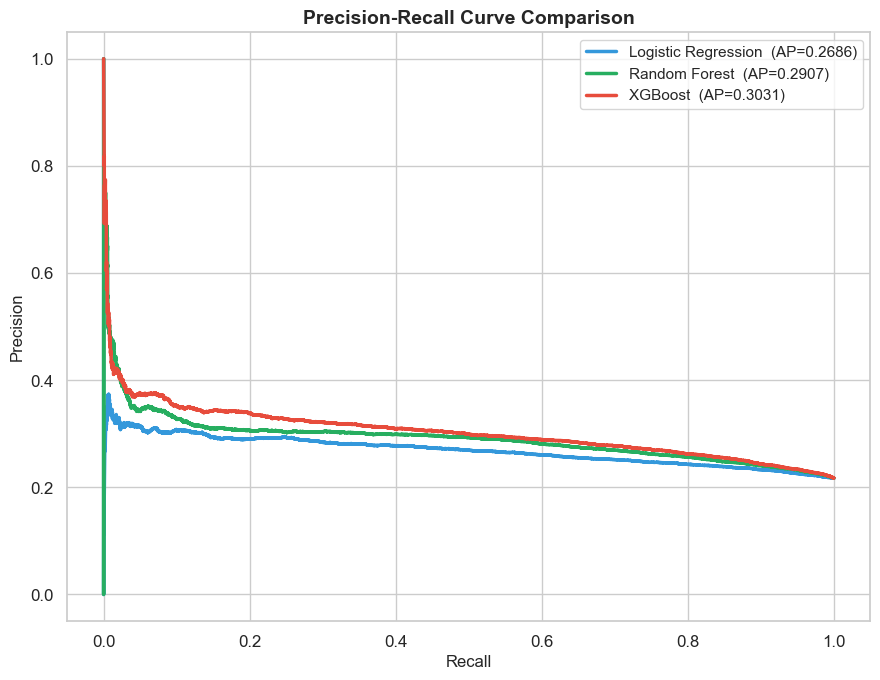

In [32]:
# Precision-Recall Curves
plt.figure(figsize=(9, 7))

for (name, _, prob), color in zip(models_info, colors):
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(rec, prec,
             label=f'{name}  (AP={ap:.4f})',
             color=color, linewidth=2.5)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve Comparison',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## 🔎 SECTION 11 — Feature Importance & SHAP

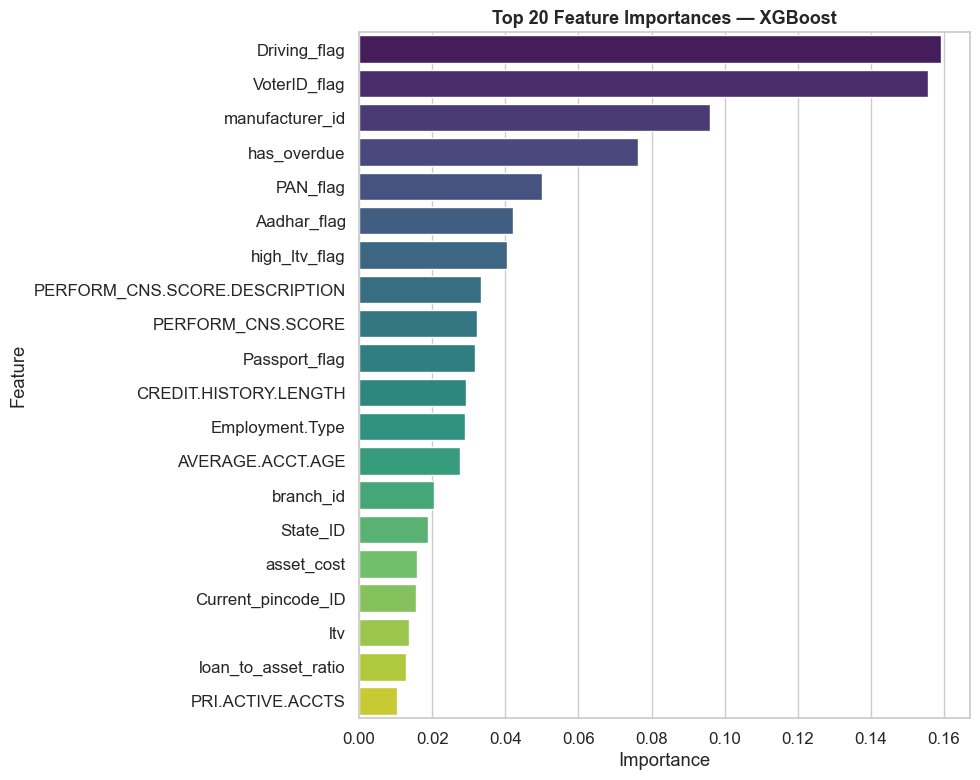

In [33]:
# XGBoost feature importance
feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature',
            data=feat_imp, palette='viridis')
plt.title('Top 20 Feature Importances — XGBoost',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

⏳ Calculating SHAP values...


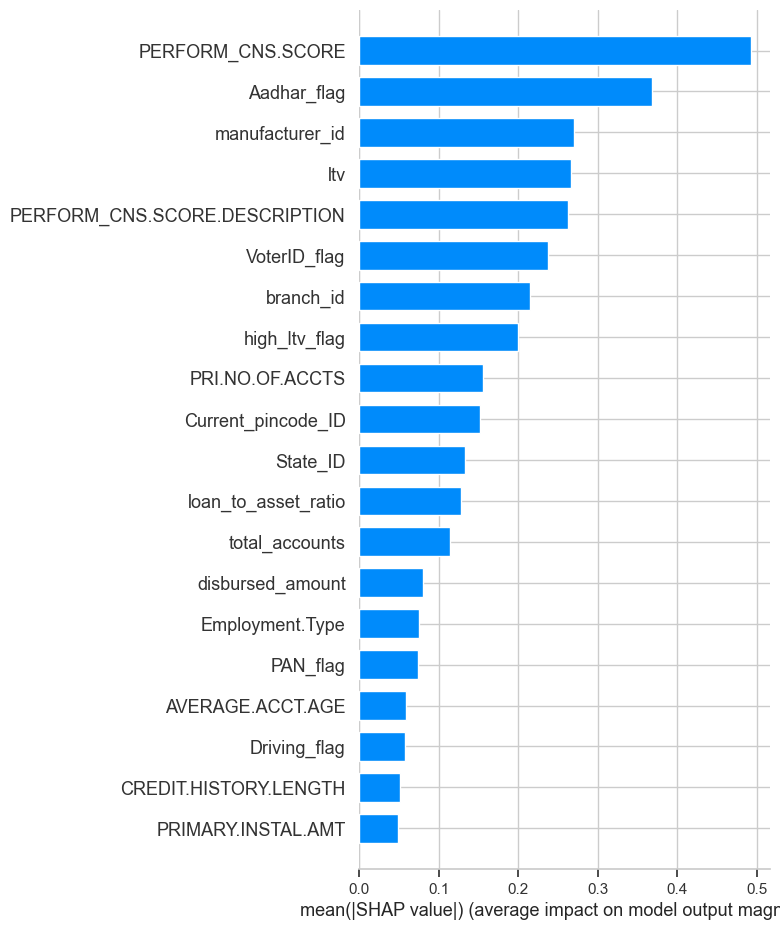

In [34]:
# SHAP summary (bar)
print('⏳ Calculating SHAP values...')
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test[:500])

plt.figure()
shap.summary_plot(shap_values, X_test[:500],
                  plot_type='bar', show=True)

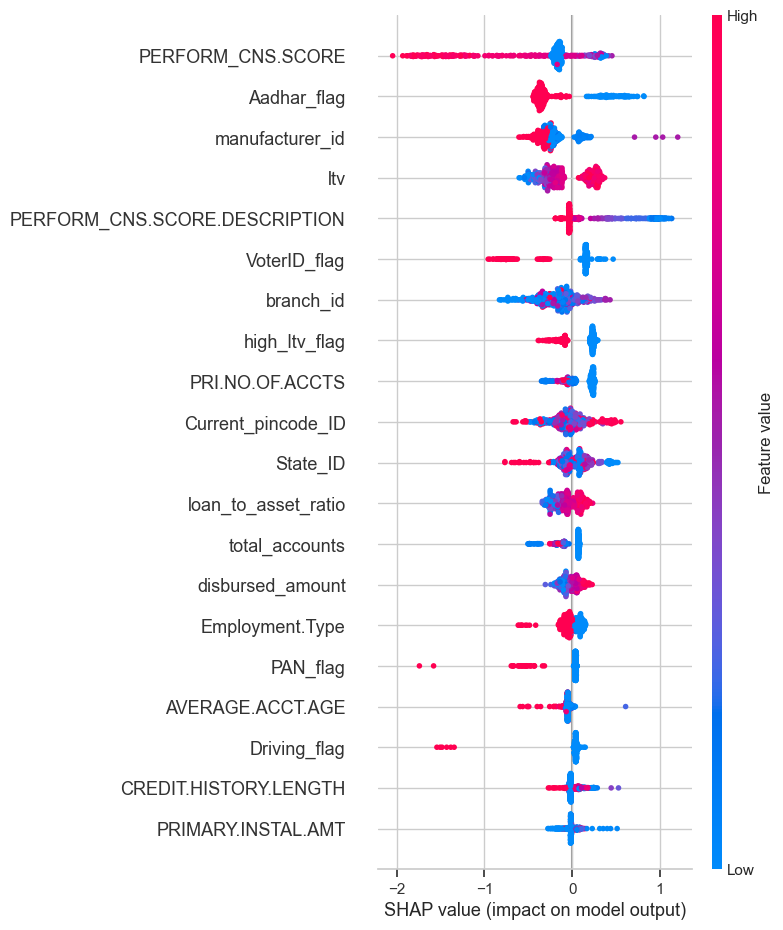

In [35]:
# SHAP beeswarm
shap.summary_plot(shap_values, X_test[:500], show=True)

---
## 💾 SECTION 12 — Save Best Model

In [36]:

MODEL_PATH   = r'D:\Mansi\loan-default-scorecard\Model\model.pkl'
COLUMNS_PATH = r'D:\Mansi\loan-default-scorecard\Model\columns.pkl'

joblib.dump(xgb, MODEL_PATH)
joblib.dump(X.columns.tolist(), COLUMNS_PATH)

print('Model saved   :', MODEL_PATH)
print('Columns saved :', COLUMNS_PATH)

Model saved   : D:\Mansi\loan-default-scorecard\Model\model.pkl
Columns saved : D:\Mansi\loan-default-scorecard\Model\columns.pkl


In [38]:
import pickle, os
os.makedirs("model", exist_ok=True)

# Save XGBoost model
with open("model/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb, f)

# Save feature names
feature_cols = list(X_train_sm.columns)
with open("model/feature_names.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

print("✅ Saved!")
print(f"Features ({len(feature_cols)}): {feature_cols}")

✅ Saved!
Features (43): ['disbursed_amount', 'asset_cost', 'ltv', 'branch_id', 'supplier_id', 'manufacturer_id', 'Current_pincode_ID', 'Employment.Type', 'State_ID', 'Employee_code_ID', 'MobileNo_Avl_Flag', 'Aadhar_flag', 'PAN_flag', 'VoterID_flag', 'Driving_flag', 'Passport_flag', 'PERFORM_CNS.SCORE', 'PERFORM_CNS.SCORE.DESCRIPTION', 'PRI.NO.OF.ACCTS', 'PRI.ACTIVE.ACCTS', 'PRI.OVERDUE.ACCTS', 'PRI.CURRENT.BALANCE', 'PRI.SANCTIONED.AMOUNT', 'PRI.DISBURSED.AMOUNT', 'SEC.NO.OF.ACCTS', 'SEC.ACTIVE.ACCTS', 'SEC.OVERDUE.ACCTS', 'SEC.CURRENT.BALANCE', 'SEC.SANCTIONED.AMOUNT', 'SEC.DISBURSED.AMOUNT', 'PRIMARY.INSTAL.AMT', 'SEC.INSTAL.AMT', 'NEW.ACCTS.IN.LAST.SIX.MONTHS', 'DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS', 'AVERAGE.ACCT.AGE', 'CREDIT.HISTORY.LENGTH', 'NO.OF_INQUIRIES', 'loan_to_asset_ratio', 'high_inquiry_flag', 'high_ltv_flag', 'total_accounts', 'active_acct_ratio', 'has_overdue']


In [39]:
cat_m = df_model.select_dtypes(include='object').columns.tolist()
print(cat_m)

[]


In [40]:
import os
print(os.listdir("model/"))

['feature_names.pkl', 'xgb_model.pkl']


In [41]:
import os
print("Notebook is running from:", os.getcwd())
print("Files in model/:", os.listdir("model/"))

Notebook is running from: C:\Users\Abhishek
Files in model/: ['feature_names.pkl', 'xgb_model.pkl']
